# Phase 2: Data Understanding

**CRISP-DM Phase Description:**  
This phase involves acquiring the data, getting familiar with it, identifying data quality problems, and detecting initial insights. A thorough understanding of the data at this stage is critical for a successful project.

---

In [35]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

---
### Task 1: Collect Initial Data

Acquire the necessary data and load it into the analysis environment. This task includes:

- **Data Acquisition:** Load data from files, databases, APIs, or other sources.
- **Initial Data Report:** Document the data source(s), the method of acquisition, and any problems encountered during loading.

**Instructions:**
1. Update the file path(s) below to point to your actual dataset(s).
2. Load the data into a Pandas DataFrame.
3. Display a small sample of the data to confirm it loaded correctly.

In [36]:
import pandas as pd

DATA_PATH = "../data/raw/uber-raw-data-apr14.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [37]:
# Verify the data loaded correctly by displaying shape and a sample
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.sample(5)

Dataset shape: 564516 rows x 4 columns


,Date/Time,Lat,Lon,Base
213637,4/30/2014 17:53:00,40.7144,-74.0164,B02598
83965,4/10/2014 16:49:00,40.7228,-74.0047,B02598
339495,4/2/2014 20:35:00,40.7171,-74.0122,B02682
109008,4/15/2014 15:17:00,40.8272,-73.9400,B02598
88698,4/11/2014 13:16:00,40.7401,-73.9895,B02598


In [38]:
# Document data source details

data_source_report = {
    "source": "Kaggle (Uber Pickups Dataset - NYC 2014)",
    "acquisition_method": "CSV download and manual placement into data/raw directory",
    "date_acquired": "2026-04-16",
    "issues_encountered": [
        "Dataset provided as a compressed ZIP file and required extraction before use"
    ]
}

data_source_report

{'source': 'Kaggle (Uber Pickups Dataset - NYC 2014)',
 'acquisition_method': 'CSV download and manual placement into data/raw directory',
 'date_acquired': '2026-04-16',
 'issues_encountered': ['Dataset provided as a compressed ZIP file and required extraction before use']}

---
### Task 2: Describe Data

Examine the "surface" properties of the acquired data. This includes:

- **Volume:** How many records (rows) and attributes (columns) does the dataset contain?
- **Field Identities:** What are the names, data types, and roles (ID, feature, target) of each column?
- **Descriptive Statistics:** What are the basic statistics (mean, median, std, min, max) of the numerical features and frequency counts for categorical features?

**Instructions:** Use Pandas built-in methods (`.info()`, `.describe()`, `.dtypes`, `.value_counts()`) to generate a comprehensive description of your data.

In [39]:
# TODO: Describe the structure and schema of your data.
# Inspect data types, non-null counts, and memory usage.
df.info()
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  564516 non-null  object 
 1   Lat        564516 non-null  float64
 2   Lon        564516 non-null  float64
 3   Base       564516 non-null  object 
dtypes: float64(2), object(2)
memory usage: 17.2+ MB
Number of rows: 564516
Number of columns: 4


In [40]:
# Generate descriptive statistics for numerical columns
df.describe()

,Lat,Lon
count,564516.000000,564516.000000
mean,40.740005,-73.976817
std,0.036083,0.050426
min,40.072900,-74.773300
25%,40.722500,-73.997700
50%,40.742500,-73.984800
75%,40.760700,-73.970000
max,42.116600,-72.066600


In [41]:
# Generate descriptive statistics for categorical columns
# nspect value counts for specific categorical columns:
for col in df.select_dtypes(include='object').columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Date/Time ---
Date/Time
4/7/2014 20:21:00     97
4/7/2014 20:22:00     87
4/30/2014 17:45:00    78
4/30/2014 18:43:00    70
4/30/2014 19:00:00    70
                      ..
4/29/2014 4:08:00      1
4/27/2014 9:26:00      1
4/29/2014 3:27:00      1
4/29/2014 3:16:00      1
4/30/2014 2:55:00      1
Name: count, Length: 41999, dtype: int64

--- Base ---
Base
B02682    227808
B02598    183263
B02617    108001
B02512     35536
B02764      9908
Name: count, dtype: int64


---
### Task 3: Explore Data

Dig deeper into the data using querying, visualisation, and statistical analysis to find initial insights, patterns, and interesting subsets. Key activities include:

- **Univariate Analysis:** Examine the distribution of individual features using histograms, box plots, and bar charts.
- **Bivariate / Multivariate Analysis:** Explore relationships between features using scatter plots, correlation matrices, and grouped summaries.
- **Initial Hypotheses:** Formulate initial hypotheses based on observed patterns.

**Instructions:** Create visualisations and run queries to understand the distributions, relationships, and patterns in your data.

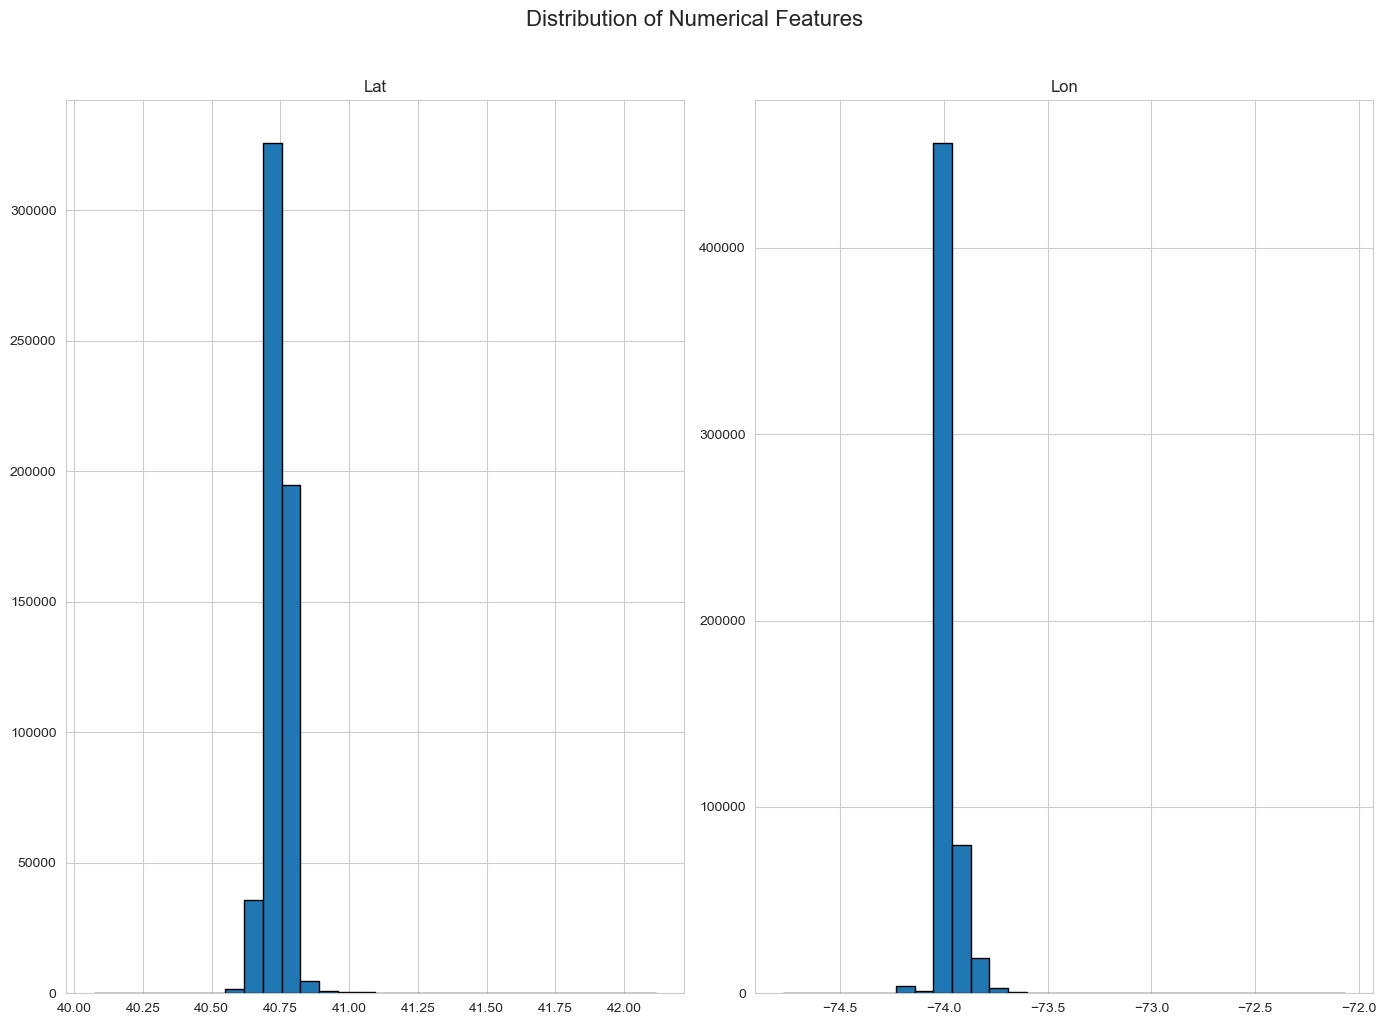

In [42]:
# TODO: Perform univariate analysis — explore distributions of individual features.

df.hist(figsize=(14, 10), bins=30, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

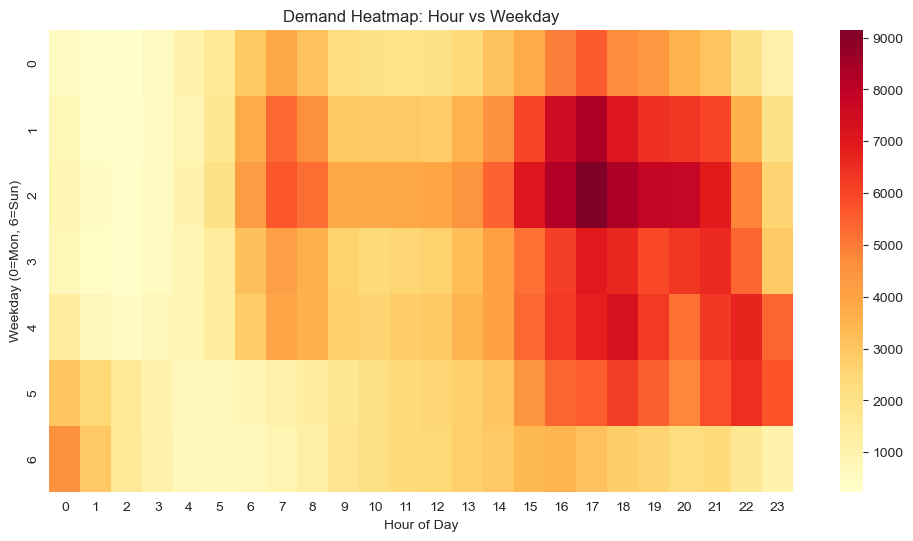

In [43]:
# TODO: Perform bivariate/multivariate analysis — explore relationships between features.
# Example: Correlation heatmap
# Convert Date/Time to datetime (if not already done)
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# Create time features
df['hour'] = df['Date/Time'].dt.hour
df['weekday'] = df['Date/Time'].dt.weekday

# Build pivot table for heatmap
heatmap_data = df.pivot_table(
    index='weekday',
    columns='hour',
    values='Base',
    aggfunc='count'
)

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd')

plt.title("Demand Heatmap: Hour vs Weekday")
plt.xlabel("Hour of Day")
plt.ylabel("Weekday (0=Mon, 6=Sun)")

plt.show()

In [ ]:
initial_insights = [
    "Insight 1: Demand is highly time-dependent, with clear peaks during late afternoon and evening hours (around 15:00–19:00), suggesting rush-hour or post-work activity.",
    
    "Insight 2: Midweek days (especially Tuesday–Thursday) show the highest demand intensity, indicating stronger weekday usage compared to weekends.",
    
    "Insight 3: Early morning hours (00:00–06:00) consistently show very low demand across all days, confirming expected off-peak behavior.",
    
    "Insight 4: Weekend patterns differ slightly—demand is more spread out and slightly elevated during late-night and evening hours compared to weekdays.",
    
    "Insight 5: Latitude and longitude distributions are tightly concentrated, indicating that the data is geographically localized rather than spread across a wide region.",
    
    "Insight 6: The narrow geographic spread suggests clustering models may identify dense, overlapping clusters rather than widely separated ones.",
    
    "Hypothesis 1: Demand is primarily driven by commuting patterns (work start/end times), leading to predictable peak hours.",
    
    "Hypothesis 2: Different clustering patterns will emerge when incorporating time-based features (hour, weekday) alongside location data.",
    
    "Hypothesis 3: Since location variance is low, temporal features will likely have more influence than spatial features in distinguishing clusters."
]

for i, insight in enumerate(initial_insights, 1):
    print(f"{i}. {insight}")

---
### Task 4: Verify Data Quality

Evaluate the completeness and correctness of the data. Check for problems that could affect the analysis:

- **Missing Values:** Identify columns with missing data, the volume, and patterns of missingness.
- **Duplicates:** Check for and report duplicate records.
- **Outliers:** Detect anomalous values using statistical methods or visualisations (box plots, z-scores).
- **Inconsistencies:** Look for data type mismatches, inconsistent formatting, or invalid entries.

**Instructions:** Systematically check for data quality issues and document your findings.

In [45]:
# TODO: Check for missing values.

# Check for missing values

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

missing_report = missing_report[missing_report['Missing Count'] > 0] \
    .sort_values('Missing %', ascending=False)

print("=== Missing Values Report ===")
print(missing_report)

print(f"\nTotal columns with missing values: {len(missing_report)}")

=== Missing Values Report ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total columns with missing values: 0


In [46]:
# TODO: Check for duplicate records.

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print("\nSample of duplicate rows:")
    print(df[df.duplicated(keep=False)].head(10))

Number of duplicate rows: 7749

Sample of duplicate rows:
              Date/Time      Lat      Lon    Base  hour  weekday
43  2014-04-01 05:44:00  40.7430 -74.0301  B02512     5        1
44  2014-04-01 05:44:00  40.7430 -74.0301  B02512     5        1
127 2014-04-01 07:25:00  40.7805 -73.9481  B02512     7        1
128 2014-04-01 07:25:00  40.7805 -73.9481  B02512     7        1
184 2014-04-01 08:25:00  40.7620 -73.9787  B02512     8        1
185 2014-04-01 08:25:00  40.7620 -73.9787  B02512     8        1
189 2014-04-01 08:29:00  40.6904 -74.1778  B02512     8        1
190 2014-04-01 08:29:00  40.6904 -74.1778  B02512     8        1
237 2014-04-01 09:49:00  40.7195 -74.0367  B02512     9        1
238 2014-04-01 09:49:00  40.7195 -74.0367  B02512     9        1


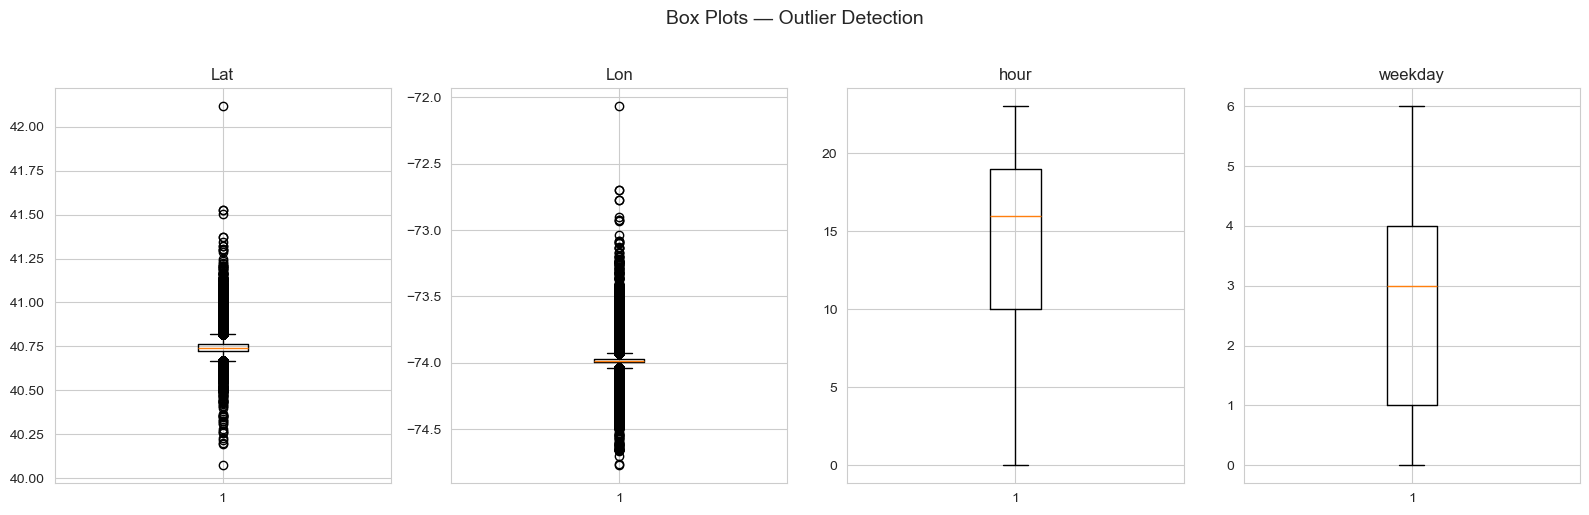

In [47]:
# TODO: Detect outliers using box plots or statistical methods.

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if numerical_cols:
     fig, axes = plt.subplots(nrows=1, ncols=len(numerical_cols), figsize=(4 * len(numerical_cols), 5))
     if len(numerical_cols) == 1:
         axes = [axes]
     for ax, col in zip(axes, numerical_cols):
         ax.boxplot(df[col].dropna())
         ax.set_title(col)
     plt.suptitle('Box Plots — Outlier Detection', fontsize=14, y=1.02)
     plt.tight_layout()
     plt.show()